<a href="https://colab.research.google.com/github/Lijan-Baral/GitHub-CST184/blob/main/Week3_Tutorial_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

3.5. Tutorial: Classifying Countries Using Decision Trees

Step 1: Setup and File Preparation

Done

Step 2: Load the Dataset

In [2]:
import pandas as pd

df = pd.read_csv("/content/sample_data/week3_policy_data.csv")
df.head()

,Country,%Renewable,CO2_per_capita,Region,Apply_Policy
0,Nepal,88,1.2,Asia,yes
1,Kenya,65,1.8,Africa,yes
2,Germany,45,6.5,Europe,no
3,India,25,1.9,Asia,yes
4,Australia,35,17.0,Oceania,no


In [3]:
#Try This: Add df.info() and df.describe() to inspect data types and basic stats.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         10 non-null     object 
 1   %Renewable      10 non-null     int64  
 2   CO2_per_capita  10 non-null     float64
 3   Region          10 non-null     object 
 4   Apply_Policy    10 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 532.0+ bytes


In [4]:
df.describe()

,%Renewable,CO2_per_capita
count,10.000000,10.000000
mean,48.300000,5.220000
std,31.283826,6.057282
min,12.000000,0.900000
25%,21.250000,1.425000
50%,40.000000,2.000000
75%,76.250000,5.875000
max,95.000000,17.000000



Step 3: Encode the Target Label

In [5]:
df["Label"] = df["Apply_Policy"].map({"yes": 1, "no": 0})
# Machine learning models require numeric labels, not text. This converts yes and no to 1 and 0 respectively.

In [6]:
#Try This: Print df[["Country", "Label"]] to verify the mapping worked.
df[["Country", "Label"]]

,Country,Label
0,Nepal,1
1,Kenya,1
2,Germany,0
3,India,1
4,Australia,0
5,Brazil,1
6,Nigeria,1
7,Sweden,0
8,Bangladesh,1
9,USA,0


Step 4: Define Features and Train the Tree

In [7]:
#What this does: Selects input features (X) and output labels (y), and trains a decision tree model with a maximum depth of 3 to avoid overfitting.
from sklearn.tree import DecisionTreeClassifier

X = df[["%Renewable", "CO2_per_capita"]]
y = df["Label"]

tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [8]:
#Try This: Change max_depth to 2 or 4 and observe
tree = DecisionTreeClassifier(max_depth=2, random_state=0)
tree.fit(X, y)


DecisionTreeClassifier(max_depth=2, random_state=0)

Step 5: Visualize the Tree

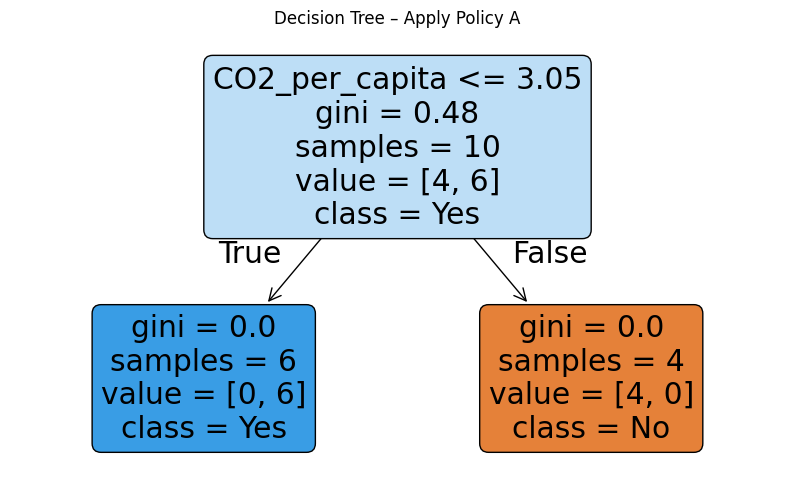

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_tree(tree, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title("Decision Tree – Apply Policy A")
plt.show()

Note: The figure shows the logical structure of the decision tree. Each node represents a condition, with outcomes labeled as "Yes" (apply policy) or "No".

What does it say about CO₂ vs renewables in each policy decision?
Answer: on CO2 part,the country with lower one leads to policy appliction. and on renewables, higher renewable further refines the decision of applying the policy.

Step 6: Make Predictions

In [10]:
new_data = pd.DataFrame({
    "%Renewable": [52, 20, 75],
    "CO2_per_capita": [1.5, 2.5, 3.0]
})

predictions = tree.predict(new_data)
print(predictions)

[1 1 1]


In [11]:
# Try This: Add new countries with different values. Predict what policy they’d qualify for.
new_data = pd.DataFrame({
    "%Renewable": [20, 80, 50],
    "CO2_per_capita": [8.0, 3.0, 1.0]
})

predictions = tree.predict(new_data)
print(predictions)

[0 1 1]


Challenge Tasks

## Step 7: Add Region Feature and Retrain Tree

To include the `Region` feature, we need to convert it into a numerical format using one-hot encoding.

In [12]:
from sklearn.preprocessing import OneHotEncoder

# Perform one-hot encoding on the 'Region' column
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
region_encoded = encoder.fit_transform(df[['Region']])
region_df = pd.DataFrame(region_encoded, columns=encoder.get_feature_names_out(['Region']))

# Display the first few rows of the encoded regions
display(region_df.head())

,Region_Africa,Region_Asia,Region_Europe,Region_North America,Region_Oceania,Region_South America
0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
# Combine the original numerical features with the new encoded region features
X_new = pd.concat([df[["%Renewable", "CO2_per_capita"]], region_df], axis=1)

# Redefine the target variable y
y_new = df["Label"]

# Retrain the decision tree with the new features
tree_with_region = DecisionTreeClassifier(max_depth=3, random_state=0)
tree_with_region.fit(X_new, y_new)

print("Decision tree retrained with %Renewable, CO2_per_capita, and Region features.")

Decision tree retrained with %Renewable, CO2_per_capita, and Region features.


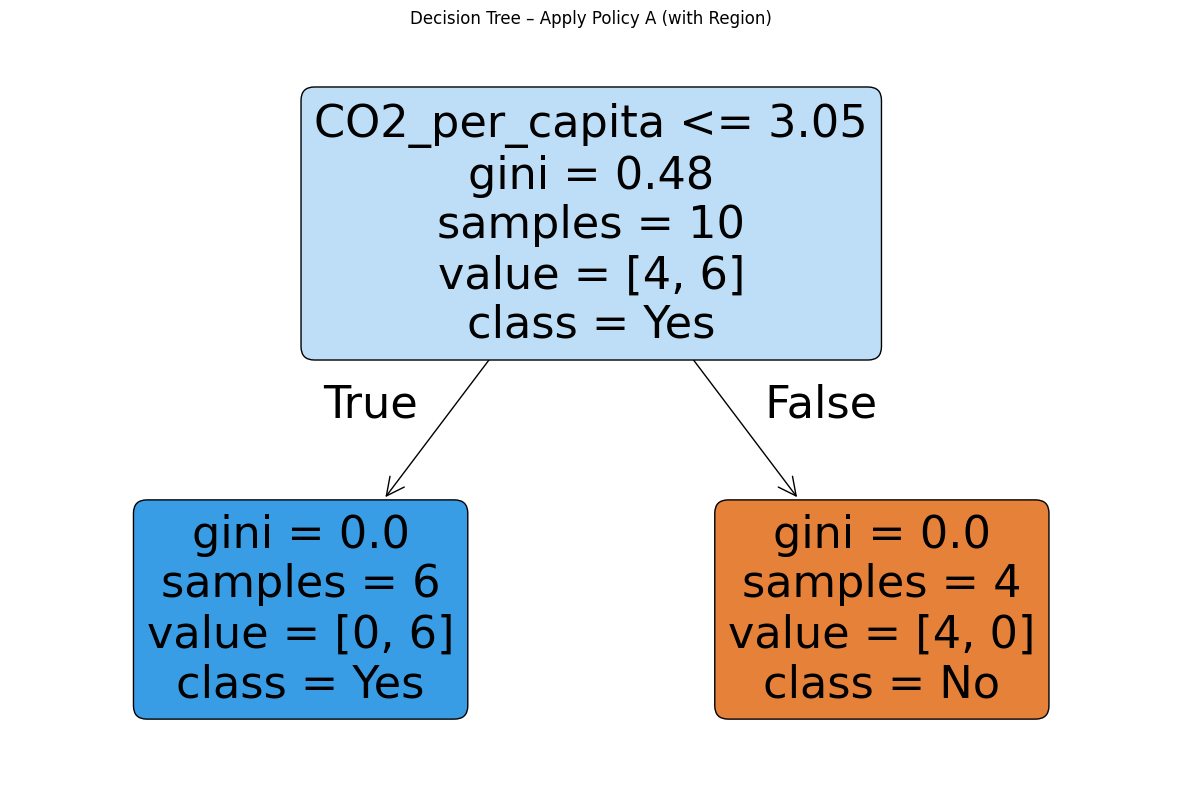

In [14]:
# For visualization
plt.figure(figsize=(15, 10)) # Adjust figure size for better readability
plot_tree(tree_with_region, feature_names=X_new.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title("Decision Tree – Apply Policy A (with Region)")
plt.show()

# Store the feature names for future use in prediction
feature_names_with_region = X_new.columns.tolist()